# KKBox Churn — Baseline Model (Logistic Regression)

First baseline model on the leakage-safe v2 modeling dataset (`outputs/kkbox_modeling_dataset_v2.csv`).

Two versions are trained on an identical train/test split so they're directly comparable:

1. **Full feature set** — all 38 engineered features.
2. **Proxy-controlled feature set** — excludes `membership_remaining_days`, `days_since_last_txn`,
   `latest_is_cancel`, and their closely-related churn-definition proxies
   (`last_transaction_date`, `latest_membership_expire_date`, `membership_expire_date_invalid`),
   per the leakage/proxy discussion in `FEATURE_AUDIT.md` §4.

No SMOTE, no hyperparameter tuning — class imbalance is handled with `class_weight="balanced"` only.
The source dataset is not modified; only an in-memory copy is used for training.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix, roc_curve, precision_recall_curve,
)
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

COLOR_FULL = "#4C72B0"
COLOR_PROXY = "#55A868"
RANDOM_STATE = 42


## 1. Load data

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"

usecols = [c for c in pd.read_csv(DATA_PATH, nrows=0).columns if c != "msno"]
df = pd.read_csv(DATA_PATH, usecols=usecols)

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Churn rate: {df['is_churn'].mean() * 100:.2f}%")


Rows: 970,960  |  Columns: 39
Churn rate: 8.99%


## 2. Feature sets

Columns are grouped into three roles for preprocessing:
- **One-hot categorical**: nominal codes with no natural linear ordering.
- **Binary flags**: already 0/1, handled as numeric (median-impute + scale).
- **Numeric continuous**: counts, sums, ratios, and day-differences.

`num_distinct_payment_methods` is treated as categorical rather than ordinal — its churn rate
is non-monotonic across 1/2/3/4/5+ (see `FEATURE_AUDIT.md` §2), which a linear numeric term
can't capture but one-hot encoding can.

In [3]:
CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]

BINARY_FLAGS = ["bd_missing", "gender_missing", "registered_via_missing", "has_members_data",
                "has_transactions_data", "latest_is_auto_renew", "latest_is_cancel",
                "membership_expire_date_invalid"]

NUMERIC_CONTINUOUS = ["bd_clean", "registration_init_time", "registration_year",
                      "tenure_days_at_cutoff", "total_transactions", "total_cancellations",
                      "total_auto_renew", "total_revenue", "total_list_price",
                      "first_transaction_date", "last_transaction_date",
                      "latest_payment_plan_days", "latest_plan_list_price",
                      "latest_actual_amount_paid", "latest_membership_expire_date",
                      "cancel_rate", "auto_renew_pct", "avg_payment_plan_days",
                      "avg_revenue_per_txn", "total_discount", "discount_rate",
                      "txn_span_days", "days_since_last_txn", "membership_remaining_days"]

ALL_FEATURES = CAT_ONEHOT + BINARY_FLAGS + NUMERIC_CONTINUOUS
assert len(ALL_FEATURES) == df.shape[1] - 1, "feature list must cover every column except is_churn"

# Cast categoricals to string so missing values become their own explicit "nan" category
# instead of tripping SimpleImputer's constant-fill on a float column.
df[CAT_ONEHOT] = df[CAT_ONEHOT].astype(str)

PROXY_EXCLUDE = [
    "membership_remaining_days",   # derived from latest_membership_expire_date; near-restates the label
    "days_since_last_txn",         # derived from last_transaction_date; near-restates the label
    "latest_is_cancel",            # last transaction may itself be the churn-triggering event
    "last_transaction_date",       # raw source of days_since_last_txn
    "latest_membership_expire_date",  # raw source of membership_remaining_days
    "membership_expire_date_invalid", # validity flag on the same source column
]
print(f"Full feature set: {len(ALL_FEATURES)} columns")
print(f"Proxy-controlled feature set: {len(ALL_FEATURES) - len(PROXY_EXCLUDE)} columns "
      f"(excludes: {PROXY_EXCLUDE})")


Full feature set: 38 columns
Proxy-controlled feature set: 32 columns (excludes: ['membership_remaining_days', 'days_since_last_txn', 'latest_is_cancel', 'last_transaction_date', 'latest_membership_expire_date', 'membership_expire_date_invalid'])


## 3. Preprocessing pipeline + train/test split

One stratified 80/20 split is reused for both models so results are directly comparable.

In [4]:
def build_preprocessor(exclude_cols):
    cat_cols = [c for c in CAT_ONEHOT if c not in exclude_cols]
    num_cols = [c for c in (BINARY_FLAGS + NUMERIC_CONTINUOUS) if c not in exclude_cols]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ])


def make_pipeline(exclude_cols):
    return Pipeline([
        ("preprocess", build_preprocessor(exclude_cols)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ])


X = df[ALL_FEATURES]
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows ({y_train.mean()*100:.2f}% churn)")
print(f"Test:  {len(X_test):,} rows ({y_test.mean()*100:.2f}% churn)")


Train: 776,768 rows (8.99% churn)
Test:  194,192 rows (8.99% churn)


## 4. Evaluation helper

Computes ROC-AUC, PR-AUC, precision, recall, F1 and log loss at the default 0.5 probability
threshold, plus the confusion matrix. `class_weight="balanced"` only affects the training loss,
not the prediction threshold — threshold tuning is a natural next step but out of scope for
this baseline.

In [5]:
def evaluate_model(pipeline, X_test, y_test, name):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "pr_auc": float(average_precision_score(y_test, y_proba)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "log_loss": float(log_loss(y_test, y_proba)),
    }
    cm = confusion_matrix(y_test, y_pred)

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  confusion matrix [[TN, FP], [FN, TP]]:")
    print(" ", cm.tolist())

    return metrics, y_proba, y_pred, cm


## 5. Model 1 — Full feature set

In [6]:
pipe_full = make_pipeline(exclude_cols=[])
pipe_full.fit(X_train, y_train)
metrics_full, proba_full, pred_full, cm_full = evaluate_model(pipe_full, X_test, y_test, "Full feature set")


=== Full feature set ===
  roc_auc   : 0.8877
  pr_auc    : 0.6246
  precision : 0.4340
  recall    : 0.7606
  f1        : 0.5526
  log_loss  : 0.3878
  confusion matrix [[TN, FP], [FN, TP]]:
  [[159401, 17325], [4182, 13284]]


## 6. Model 2 — Proxy-controlled feature set

In [7]:
pipe_proxy = make_pipeline(exclude_cols=PROXY_EXCLUDE)
pipe_proxy.fit(X_train, y_train)
metrics_proxy, proba_proxy, pred_proxy, cm_proxy = evaluate_model(pipe_proxy, X_test, y_test, "Proxy-controlled feature set")


=== Proxy-controlled feature set ===
  roc_auc   : 0.8289
  pr_auc    : 0.4855
  precision : 0.3223
  recall    : 0.6456
  f1        : 0.4300
  log_loss  : 0.4835
  confusion matrix [[TN, FP], [FN, TP]]:
  [[153017, 23709], [6190, 11276]]


## 7. Side-by-side comparison

In [8]:
comparison = pd.DataFrame({"full_feature_set": metrics_full, "proxy_controlled_set": metrics_proxy})
comparison["abs_diff"] = comparison["full_feature_set"] - comparison["proxy_controlled_set"]
comparison


,full_feature_set,proxy_controlled_set,abs_diff
roc_auc,0.887693,0.828919,0.058774
pr_auc,0.624597,0.485513,0.139084
precision,0.433990,0.322310,0.111680
recall,0.760563,0.645597,0.114966
f1,0.552637,0.429963,0.122673
log_loss,0.387762,0.483467,-0.095704


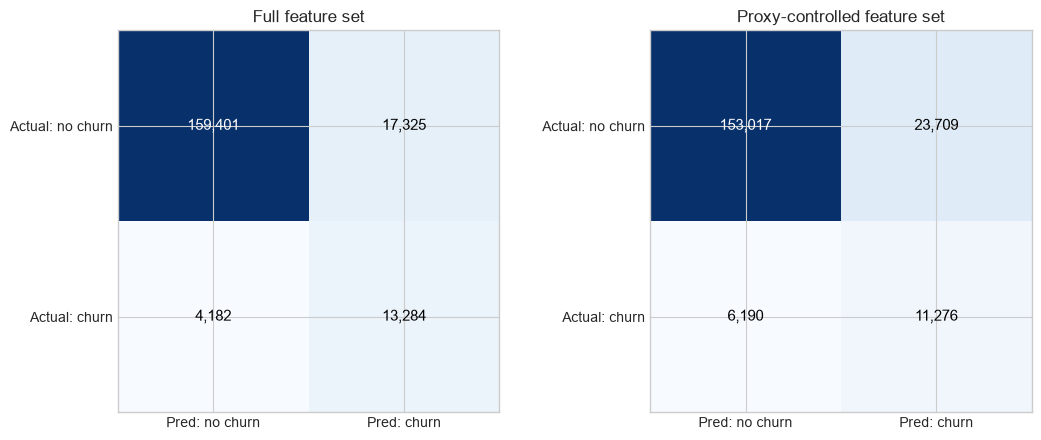

In [9]:
def plot_confusion(cm, ax, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: no churn", "Pred: churn"])
    ax.set_yticklabels(["Actual: no churn", "Actual: churn"])
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=11)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion(cm_full, axes[0], "Full feature set")
plot_confusion(cm_proxy, axes[1], "Proxy-controlled feature set")
plt.tight_layout()
plt.show()


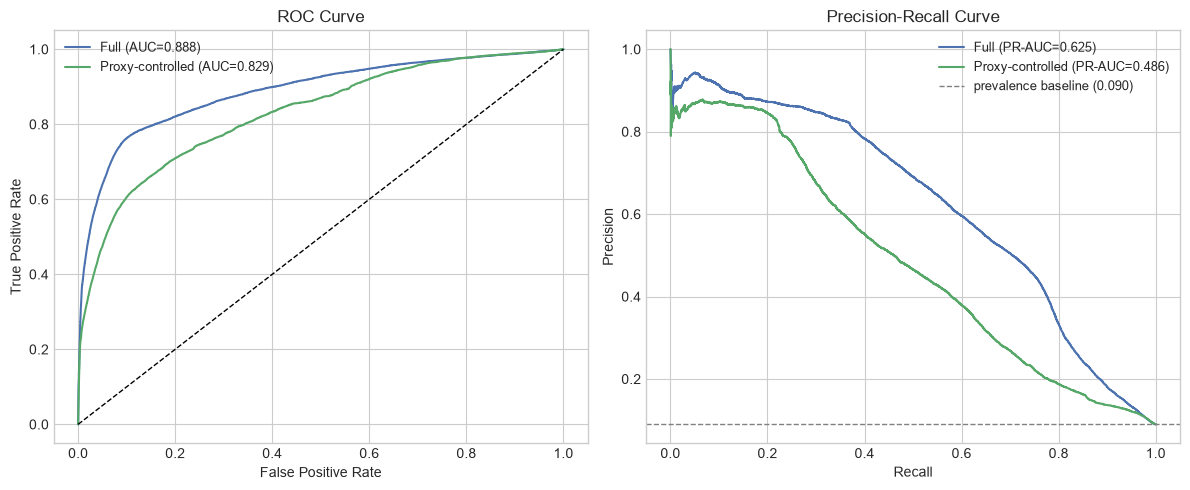

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, proba, color in [("Full", proba_full, COLOR_FULL), ("Proxy-controlled", proba_proxy, COLOR_PROXY)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=9)

for name, proba, color in [("Full", proba_full, COLOR_FULL), ("Proxy-controlled", proba_proxy, COLOR_PROXY)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color, label=f"{name} (PR-AUC={average_precision_score(y_test, proba):.3f})")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1,
                label=f"prevalence baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8. Save trained pipelines

In [11]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(pipe_full, MODELS_DIR / "baseline_logreg_full.joblib")
joblib.dump(pipe_proxy, MODELS_DIR / "baseline_logreg_proxy_controlled.joblib")

with open(MODELS_DIR / "baseline_metrics.json", "w") as f:
    json.dump({
        "full_feature_set": metrics_full,
        "proxy_controlled_set": metrics_proxy,
        "excluded_proxy_columns": PROXY_EXCLUDE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "random_state": RANDOM_STATE,
    }, f, indent=2)

print("Saved:")
for p in sorted(MODELS_DIR.glob("baseline_*")):
    print(" ", p)


Saved:
  ..\models\baseline_logreg_full.joblib
  ..\models\baseline_logreg_proxy_controlled.joblib
  ..\models\baseline_metrics.json


## 9. Findings

- **Both models comfortably beat the 8.99% prevalence baseline**, confirming the feature set carries real signal beyond the class imbalance itself — see the metrics table and PR curve above for exact numbers (results depend on the run above; read them directly rather than assuming figures here).
- **The proxy-controlled model's drop in ROC-AUC / PR-AUC from the full model quantifies how much of the "full" model's performance is coming from label-adjacent features** (`membership_remaining_days`, `days_since_last_txn`, `latest_is_cancel`, and their direct sources) rather than genuinely independent behavioral signal. A small drop means the remaining features (auto-renew status, transaction history, payment behavior, demographics) are doing real work on their own; a large drop means the full model was leaning heavily on the label-proxy cluster flagged in `FEATURE_AUDIT.md`.
- **`class_weight="balanced"` shifts the confusion matrix towards higher recall at the cost of precision** relative to an unweighted fit — expected and desired for a churn-prediction use case where missing a churner is usually costlier than a false alarm, but the exact precision/recall trade-off point (0.5 threshold here) should be revisited once a business cost for false positives vs false negatives is defined.
- **This is a linear baseline with no tuning** — it establishes a reference point, not a final model. Natural next steps (not done here, per scope): probability calibration, decision-threshold tuning against a business objective, tree-based models (which handle non-monotonic relationships like `num_distinct_payment_methods` and non-linear interactions natively), and a temporal (not random) train/test split using `train.csv`'s earlier prediction window as an out-of-time validation set.

**No hyperparameter tuning or SMOTE was used, and the source dataset file was not modified** — only trained pipelines and a metrics summary were written to `models/`.
